# Create a Forecast plot given a stored model

### Notebook Configuration

In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)

### Imports

In [2]:
import matplotlib.pyplot as plt

plt.style.use("bmh")
plt.rcParams["axes.axisbelow"] = True
import numpy as np
import pandas
import pandas as pd
from pandas import DataFrame, Index, Series, Timedelta, Timestamp
import matplotlib.dates as mdates
rng = np.random.default_rng()
np.set_printoptions()

import torch
import torchinfo
from torch import Tensor, jit, tensor
from torch.utils.data import DataLoader
from copy import deepcopy

INFO:numexpr.utils:Note: NumExpr detected 24 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


### Enter Path and Name

In [3]:
ID = (439, 15325)  # the Run_id / Experiment_id we want to plot.

# files:  2021-11-12T00:52:10 2021-11-12T00:51:55 2021-11-12T00:51:48
# "checkpoints/2021-11-15T12:05:00/LinODEnet-0"
# "checkpoints/LinODEnet/KIWI_RUNS/skew_allways/2021-11-15T16:05:41/LinODEnet-0"
# "adam/2021-11-15T20:38:52/LinODEnet-0"
PATH = "checkpoints/LinODEnet/KIWI_RUNS/"
NAME = "ReZero+ResNet+NRMSE/2021-12-15T02:29:16/LinODEnet-4"
# the model checkpoint, should be a zip-archive created by torch.save / torch.jit.save
MODEL_FILE = PATH + NAME
DEVICE = torch.device("cpu")
DTYPE = torch.float32
NAN = tensor(float("nan"), dtype=DTYPE, device=DEVICE)

tensor(nan)

## Load the Model

In [4]:
model = torch.jit.load(MODEL_FILE, torch.device("cpu"))
torchinfo.summary(model)

Layer (type:depth-idx)                                  Param #
LinODEnet                                               --
├─ConcatEmbedding: 1-1                                  113
├─ConcatProjection: 1-2                                 --
├─ResNet: 1-3                                           --
│    └─Sequential: 2-1                                  --
│    │    └─Sequential: 3-1                             33,025
│    │    └─Sequential: 3-2                             33,025
│    │    └─Sequential: 3-3                             33,025
│    │    └─Sequential: 3-4                             33,025
│    │    └─Sequential: 3-5                             33,025
├─LinODECell: 1-4                                       16,384
├─ResNet: 1-5                                           --
│    └─Sequential: 2-2                                  --
│    │    └─Sequential: 3-6                             33,025
│    │    └─Sequential: 3-7                             33,025
│    │    └─Sequen

## Import Task

In [6]:
from tsdm.tasks import KIWI_RUNS_TASK

task = KIWI_RUNS_TASK()
assert ID in task.splits[(0, "train")][0].index
TRAINLOADER = task.dataloaders[(0, "train")]
EVALLOADER = task.dataloaders[(0, "test")]

dloader = TRAINLOADER
dataset = dloader.dataset[ID]
preprocessor = deepcopy(dloader.preprocessor)
sampler = deepcopy(dloader.sampler[ID])
sampler.shuffle = False
LOADER = DataLoader(dataset, sampler=sampler)
slices = Series(LOADER)

ts = task.timeseries
ts = ts.loc[ID].astype("float32")

INFO:tsdm.datasets.base._base:KIWI_RUNS: START cleaning dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS/timeseries already exists, skipping.
INFO:tsdm.datasets.base._base:KIWI_RUNS/metadata already exists, skipping.
INFO:tsdm.datasets.base._base:KIWI_RUNS/units already exists, skipping.
INFO:tsdm.datasets.base._base:KIWI_RUNS: DONE cleaning dataset
INFO:tsdm.datasets.base._base:KIWI_RUNS: START loading dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS/timeseries: START loading dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS/timeseries: DONE loading dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS/metadata: START loading dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS/metadata: DONE loading dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS/units: START loading dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS/units: DONE loading dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS: DONE loading dataset!


variable,Flow_Air,StirringSpeed,Temperature,Acetate,Base,Cumulated_feed_volume_glucose,Cumulated_feed_volume_medium,DOT,Glucose,OD600,Probe_Volume,pH,Fluo_GFP,InducerConcentration,Volume
measurement_time,,,,,,,,,,,,,,,
2020-12-09 09:10:09,0.0,0.0,36.389999,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN
2020-12-09 09:10:19,0.0,0.0,NaN,NaN,NaN,0.0,0.000000,0.000000,NaN,NaN,0.0,7.27,NaN,0.00,NaN
2020-12-09 09:10:24,0.0,100.0,NaN,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN
2020-12-09 09:10:25,0.0,100.0,36.130001,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN
2020-12-09 09:10:34,0.0,100.0,NaN,NaN,NaN,0.0,0.000000,0.000000,NaN,NaN,0.0,7.28,NaN,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-09 23:31:40,10.0,0.0,NaN,NaN,NaN,2431.0,2188.030029,52.720001,NaN,NaN,3600.0,6.44,NaN,0.05,NaN
2020-12-09 23:31:42,0.0,0.0,NaN,NaN,NaN,2431.0,2188.030029,NaN,NaN,NaN,3600.0,NaN,NaN,0.05,NaN
2020-12-09 23:31:51,0.0,0.0,NaN,NaN,NaN,2431.0,2188.030029,52.950001,NaN,NaN,3600.0,6.44,NaN,0.05,NaN


### Helper Function for Batch post-processing

In [70]:
def prep_batch(batch: tuple[Tensor, Tensor]):
    """Get batch and create model inputs and targets."""
    T, X = batch
    targets = X[..., task.observation_horizon :, task.targets.index].clone()
    # assert targets.shape == (BATCH_SIZE, PRD_HORIZON, len(TASK.targets))
    originals = X.clone()
    inputs = X.clone()
    inputs[:, task.observation_horizon :, task.targets.index] = NAN
    inputs[:, task.observation_horizon :, task.observables.index] = NAN
    # assert inputs.shape == (BATCH_SIZE, HORIZON, NUM_DIM)
    return T, inputs, targets, originals

## Helper function to create the plot

In [71]:
def make_plot(axes, task, batch):
    """Helper function to create plot automatically."""
    # batch = slices[0]
    times, inputs, targets, originals = (x.to(device="cpu") for x in prep_batch(batch))
    outputs = model(times, inputs)

    times = times[0].detach().cpu()
    inputs = inputs[0].detach().cpu()
    outputs = outputs[0].detach().cpu()
    targets = targets[0].detach().cpu()
    originals = originals[0].detach().cpu()

    times.shape, outputs.shape, inputs.shape, targets.shape, originals.shape
    reconstructed = preprocessor.decode( (times, outputs) ).astype("float32")

    for ax, (idx, target) in zip(axes.flatten(), task.targets.items()):
        color = next(ax._get_lines.prop_cycler)['color']
        data = originals[:, idx]
        mask = ~np.isnan(data)
        ax.plot(
            reconstructed.index[:task.observation_horizon],
            reconstructed.iloc[:task.observation_horizon, idx],
            ls=":",
            lw=0.5,
            color=color,
        )
        ax.plot(
            reconstructed.index[task.observation_horizon:],
            reconstructed.iloc[task.observation_horizon:, idx],
            ls="-",
            lw=0.5,
            color=color,
        )
        print(reconstructed)

### Create the Raw data plot

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …
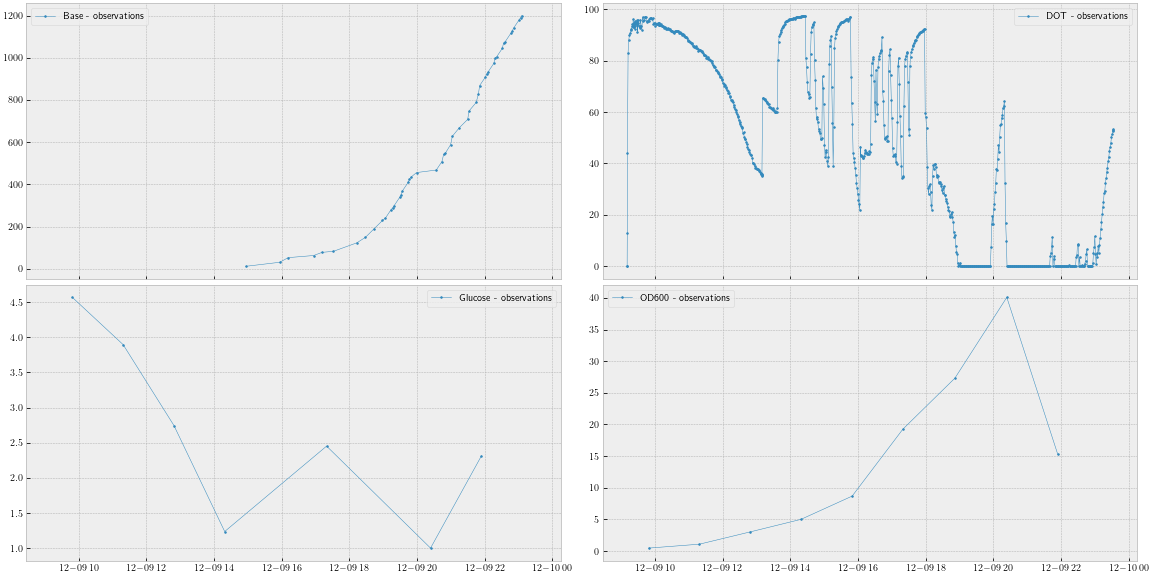

In [72]:
%matplotlib widget

fig, axes = plt.subplots(
    nrows=2, ncols=2, sharex=True, figsize=(16, 8), constrained_layout=True
)

for ax, (idx, target) in zip(axes.flatten(), task.targets.items()):
    data = ts[target]
    times = ts.index.values
    mask = ~np.isnan(data)
    ax.plot(
        times[mask],
        data[mask],
        ls="-",
        lw=0.5,
        marker=".",
        ms=3,
    )
    ax.legend([f"{target} - observations"])

### Add the model Forecast Plots

In [73]:
batches = slices.iloc[[0, 300, 600, 900, 1200]]

for batch in batches:
    make_plot(axes, task, batch)

fig.savefig(f"{NAME.replace(r'/', r'_')}.pdf")

s
                     Flow_Air  StirringSpeed  Temperature   Acetate  \
measurement_time                                                      
2020-12-09 09:10:09  5.944445     629.187012    36.877598  0.010565   
2020-12-09 09:10:19  5.913387     631.228699    36.795296 -0.018876   
2020-12-09 09:10:24  5.903603     983.123535    36.687164 -0.045481   
2020-12-09 09:10:25  5.782441    1225.746216    36.514866 -0.063883   
2020-12-09 09:10:34  5.616436    1006.939331    36.470345 -0.077681   
...                       ...            ...          ...       ...   
2020-12-09 09:50:50  5.090141    1314.396851    37.514534 -1.103122   
2020-12-09 09:50:59  5.082239    1306.364014    37.458443 -1.107442   
2020-12-09 09:52:02  5.067916    1297.271362    37.535439 -1.111524   
2020-12-09 09:52:11  5.062820    1279.327393    37.474453 -1.115817   
2020-12-09 09:53:13  5.051481    1275.051270    37.549049 -1.119915   

                          Base  Cumulated_feed_volume_glucose  \
measureme

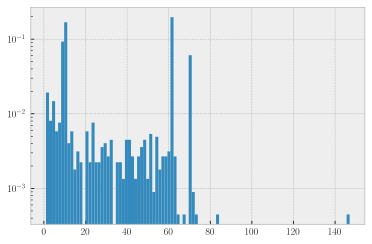

In [80]:
%matplotlib inline
delta_t = ts.index.to_series().diff().dropna().dt.total_seconds().values

plt.hist(delta_t, bins=100, density=True, log=True);

In [75]:
plt.hist?

Signature:
plt.hist(
    x,
    bins=None,
    range=None,
    density=False,
    weights=None,
    cumulative=False,
    bottom=None,
    histtype='bar',
    align='mid',
    orientation='vertical',
    rwidth=None,
    log=False,
    color=None,
    label=None,
    stacked=False,
    *,
    data=None,
    **kwargs,
)
Docstring:
Plot a histogram.

Compute and draw the histogram of *x*.  The return value is a tuple
(*n*, *bins*, *patches*) or ([*n0*, *n1*, ...], *bins*, [*patches0*,
*patches1*, ...]) if the input contains multiple data.  See the
documentation of the *weights* parameter to draw a histogram of
already-binned data.

Multiple data can be provided via *x* as a list of datasets
of potentially different length ([*x0*, *x1*, ...]), or as
a 2D ndarray in which each column is a dataset.  Note that
the ndarray form is transposed relative to the list form.

Masked arrays are not supported.

The *bins*, *range*, *weights*, and *density* parameters behave as in
`numpy.histogram`.

P

In [39]:
ts.index.is_monotonic_increasing

True

measurement_time
2020-12-09 09:10:19   0 days 00:00:10
2020-12-09 09:10:24   0 days 00:00:05
2020-12-09 09:10:25   0 days 00:00:01
2020-12-09 09:10:34   0 days 00:00:09
2020-12-09 09:10:39   0 days 00:00:05
                            ...      
2020-12-09 23:31:40   0 days 00:00:10
2020-12-09 23:31:42   0 days 00:00:02
2020-12-09 23:31:51   0 days 00:00:09
2020-12-09 23:32:02   0 days 00:00:11
2020-12-09 23:32:05   0 days 00:00:03
Name: measurement_time, Length: 1528, dtype: timedelta64[ns]